# Tesla Deliveries and Production Data Analysis

## Objective
Analyze Tesla deliveries and production trends using machine learning and time series forecasting.

In [ ]:
%pip install pandas numpy matplotlib seaborn scikit-learn prophet joblib

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

In [ ]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


DATA PREPROCESSING

In [ ]:
print(df.shape)
print(df.columns)
print(df.dtypes)
print(df.isnull().sum())


(2640, 12)
Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')
Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


In [ ]:
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(DAY=1))
df[['Year', 'Month', 'Date']].head()

,Year,Month,Date
0,2023,5,2023-05-01
1,2015,2,2015-02-01
2,2019,1,2019-01-01
3,2021,2,2021-02-01
4,2016,12,2016-12-01


In [ ]:
df = df.sort_values('Date')
df.reset_index(drop=True, inplace=True)

df[['Date', 'Estimated_Deliveries']].head()

,Date,Estimated_Deliveries
0,2015-01-01,12446
1,2015-01-01,11446
2,2015-01-01,8803
3,2015-01-01,6367
4,2015-01-01,8795


EXPLORATORY DATA ANALYSIS

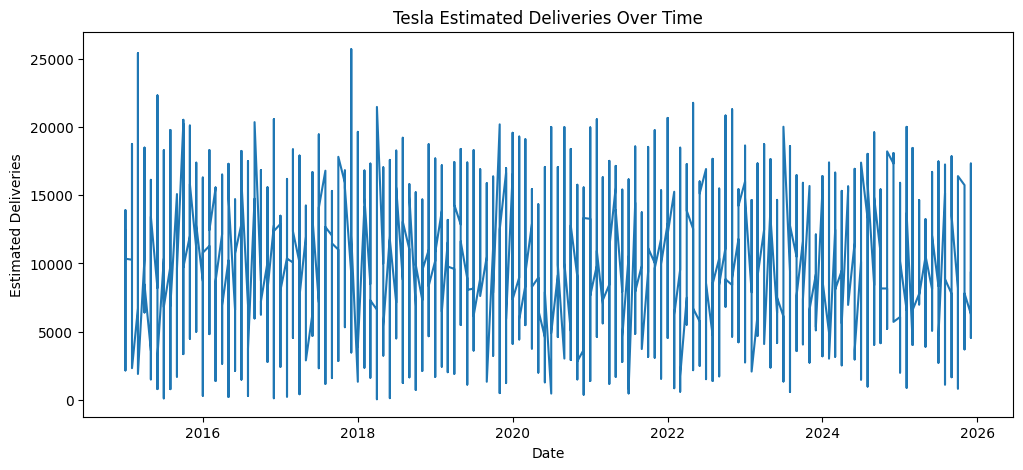

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(df['Date'], df['Estimated_Deliveries'])

plt.title("Tesla Estimated Deliveries Over Time")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")

plt.show()

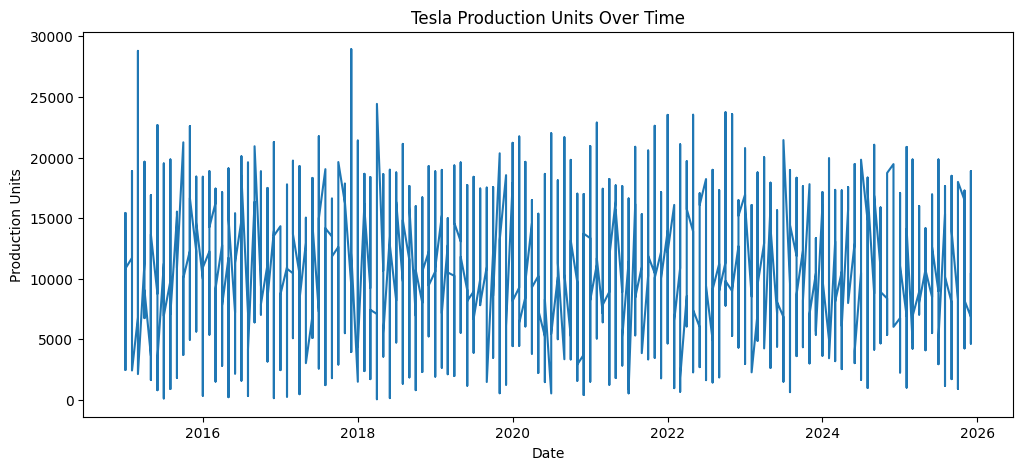

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(df['Date'], df['Production_Units'])

plt.title("Tesla Production Units Over Time")
plt.xlabel("Date")
plt.ylabel("Production Units")

plt.show()

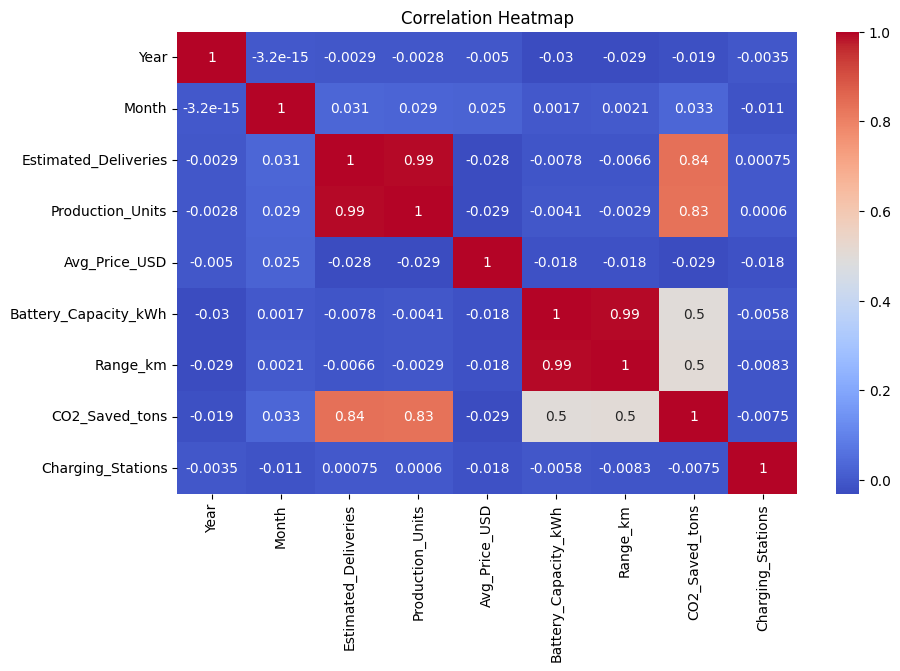

In [ ]:
# HEATMAP
import seaborn as sns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10,6))

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

FEATURE ENGINEERING

In [ ]:
# Create lag features
df['Lag_1_Deliveries'] = df['Estimated_Deliveries'].shift(1)
df['Lag_2_Deliveries'] = df['Estimated_Deliveries'].shift(2)
df['Rolling_Mean_3'] = df['Estimated_Deliveries'].rolling(window=3).mean()

# Growth rate
df['Growth_Rate'] = df['Estimated_Deliveries'].pct_change()

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Lag_1_Deliveries,Lag_2_Deliveries,Rolling_Mean_3,Growth_Rate
0,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01,NaN,NaN,NaN,NaN
1,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01,12446.0,NaN,NaN,-0.080347
2,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01,11446.0,12446.0,10898.333333,-0.230910
3,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01,8803.0,11446.0,8872.000000,-0.276724
4,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01,6367.0,8803.0,7988.333333,0.381341


In [ ]:

df.isnull().sum()

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


In [ ]:
df = df.dropna()

df.reset_index(drop=True, inplace=True)

df.shape

(2638, 17)

In [ ]:
# Check categorical columns
print(df.select_dtypes(include='object').columns)
df = pd.get_dummies(
    df,
    columns=['Region', 'Model', 'Source_Type'],
    drop_first=True
)

print(df.shape)
X = df.drop(columns=['Estimated_Deliveries', 'Date'])

# Target
y = df['Estimated_Deliveries']

print(X.shape)
print(y.shape)

Index(['Region', 'Model', 'Source_Type'], dtype='object')
(2638, 23)
(2638, 21)
(2638,)


In [ ]:
split_index = int(len(df) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (2110, 21)
Testing set: (528, 21)


TRAIN MODEL


LINEAR REGRESSION

In [ ]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [ ]:
# Predictions
y_pred_lr = lr_model.predict(X_test)
print(y_pred_lr[:5])

[ 8910. 10819.  5341.  8195.  8179.]


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Metrics
mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 1.3303082541273342e-11
RMSE: 1.6252273809117727e-11
R2 Score: 1.0


RANDOM FOREST

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Results
MAE: 326.52293560606057
RMSE: 404.73642824612637
R2 Score: 0.9876792021361878


In [ ]:
# Model comparison table

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae, mae_rf],
    'RMSE': [rmse, rmse_rf],
    'R2 Score': [r2, r2_rf]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.330308e-11,1.625227e-11,1.000000
1,Random Forest,3.265229e+02,4.047364e+02,0.987679


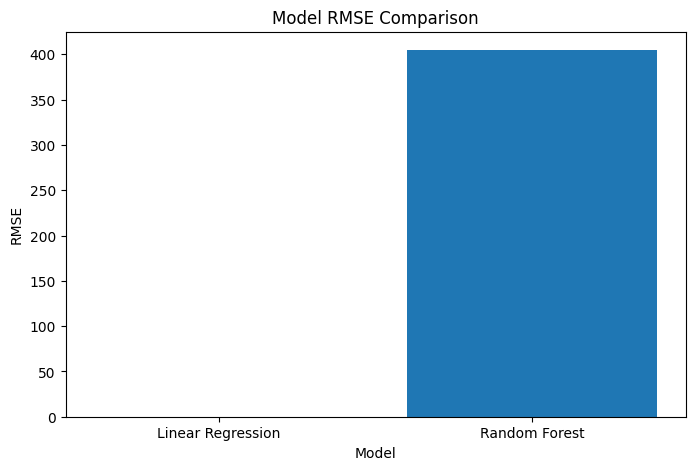

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(results['Model'], results['RMSE'])

plt.title("Model RMSE Comparison")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.show()

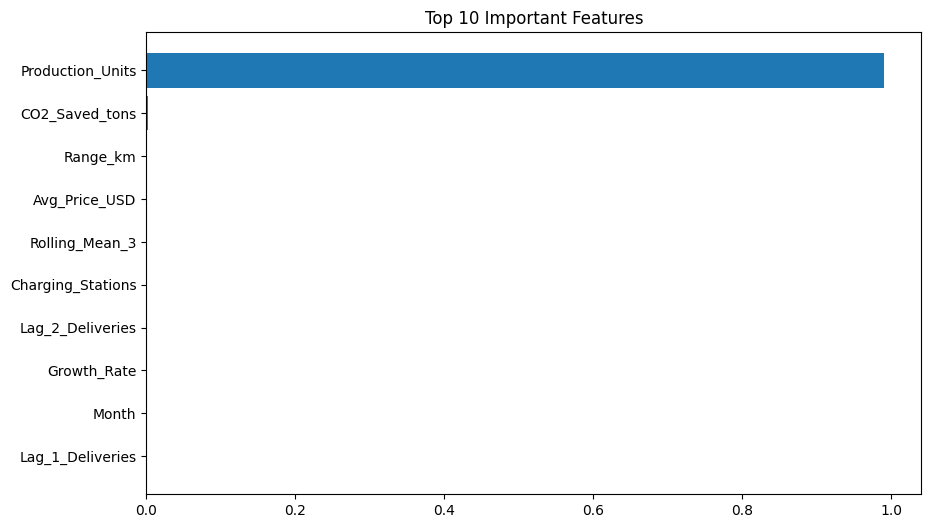

In [ ]:
# Feature importance from Random Forest

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})


importance = importance.sort_values(by='Importance', ascending=False)

top_features = importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(top_features['Feature'], top_features['Importance'])

plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
from prophet import Prophet

print("Prophet installed successfully!")

Prophet installed successfully!


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best Score: 0.9883689731678215


In [ ]:
best_rf = grid_search.best_estimator_

y_pred_best = best_rf.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_best))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_best)))

R2 Score: 0.9876792021361878
RMSE: 404.73642824612637


FORECASTING

In [ ]:
forecast_df = df[['Date', 'Estimated_Deliveries']].copy()

forecast_df.columns = ['ds', 'y']

forecast_df.head()

,ds,y
0,2015-01-01,8803
1,2015-01-01,6367
2,2015-01-01,8795
3,2015-01-01,2161
4,2015-01-01,11986


In [ ]:
from prophet import Prophet

prophet_model = Prophet()

prophet_model.fit(forecast_df)

print("Prophet model trained successfully!")

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Prophet model trained successfully!


In [ ]:
future = prophet_model.make_future_dataframe(
    periods=12,
    freq='M'
)

future.tail()

/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


,ds
139,2026-07-31
140,2026-08-31
141,2026-09-30
142,2026-10-31
143,2026-11-30


In [ ]:
forecast = prophet_model.predict(future)

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
139,2026-07-31,10654.533344,5684.826578,15378.799782
140,2026-08-31,8973.755252,4385.044434,14369.966923
141,2026-09-30,10346.295249,5415.589025,15396.578388
142,2026-10-31,10181.461091,5234.349285,15151.996745
143,2026-11-30,10391.721622,5322.764794,15131.395649


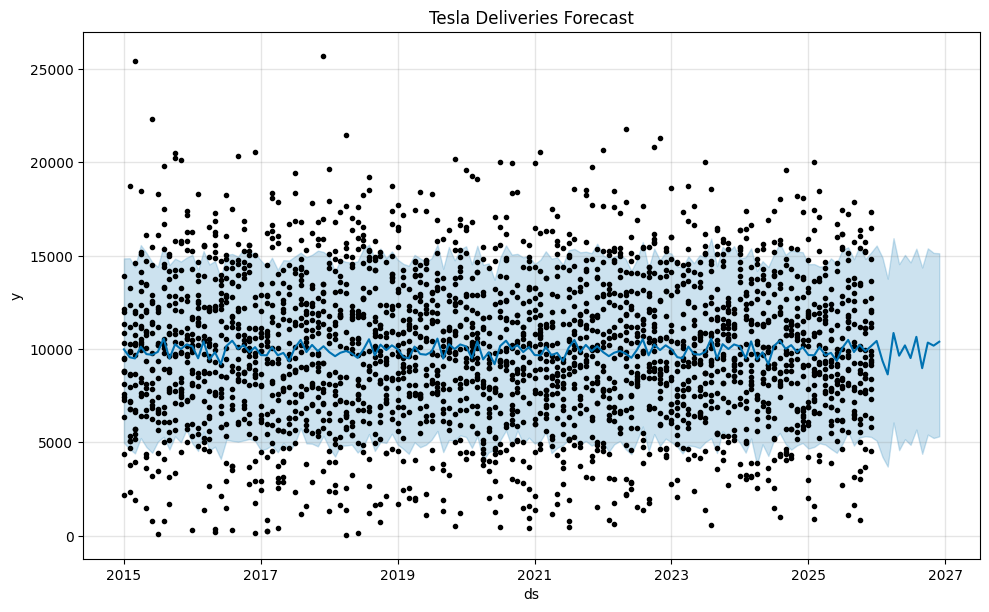

In [ ]:
fig = prophet_model.plot(forecast)

plt.title("Tesla Deliveries Forecast")
plt.show()

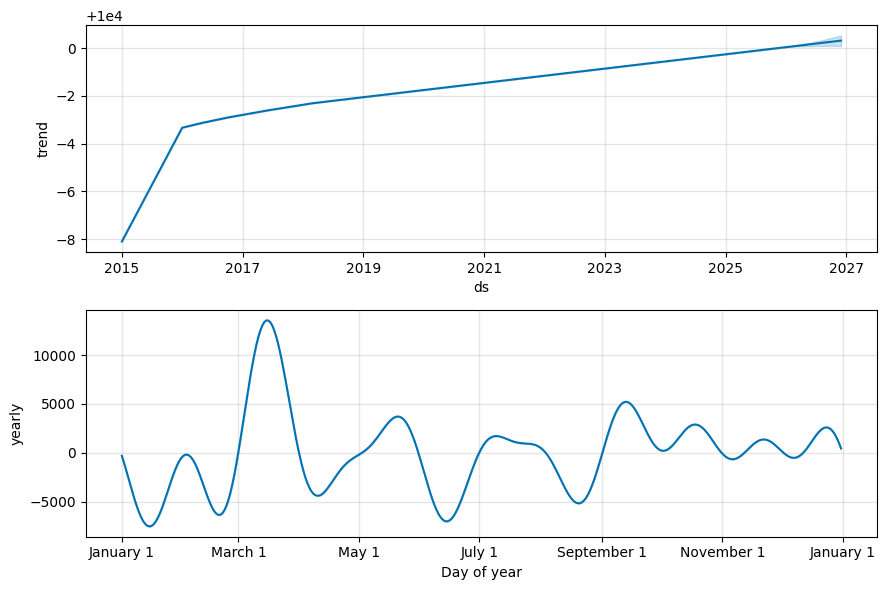

In [ ]:
fig2 = prophet_model.plot_components(forecast)

plt.show()

In [ ]:
forecast[['ds', 'yhat']].tail(12)

,ds,yhat
132,2025-12-31,10434.155621
133,2026-01-31,9373.580038
134,2026-02-28,8640.788166
135,2026-03-31,10860.300527
136,2026-04-30,9644.421574
137,2026-05-31,10195.160764
138,2026-06-30,9516.178498
139,2026-07-31,10654.533344
140,2026-08-31,8973.755252
141,2026-09-30,10346.295249
